In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 1
T2 = .5

N = 5
dim = 2
trotter_dt = .001

# amp_damp_channel = AmplitudeDamping(T1, num_qubits=N, hilbert_space_dim=dim)
# phase_damp_channel = PhaseDamping(T1, T2, num_qubits=N, hilbert_space_dim=dim)
# trotter = TrotterGroup(
#     continuous_operators=[amp_damp_channel],
#     trotter_dt=trotter_dt,
# )

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qubit")

In [3]:
# creating gates
# creating the set of cnots
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

x_gate = qt.Qobj([[0, 1],[1, 0]])

C:\Users\girgi\AppData\Local\Temp\ipykernel_16412\2557974889.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_16412\2557974889.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_16412\2557974889.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot

In [4]:
# create fidelity function
# add others if you want another metric 
def hilbert_schmidt_fid_func(rho, sigma):
    return np.abs((sigma * rho).tr()) / np.sqrt((rho * rho).tr() * (sigma * sigma).tr())

# def fid(initial_state, evolved_state):
#     # initial state is a vector, the evolved state is a density matrix 
#     return initial_state * evolved_state * initial_state.dag()

In [5]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [6]:
# build circuit 
# delay gate for ideal setup 
states = []
fids = []
# new_fid = []
duration_delay = .4
delay_state = trotter.apply(rho_encoded, duration= duration_delay, unitary=[tensor([qt.qeye(dim)] * N)])
for i in range(len(delay_state)):
    a = qt.ptrace(delay_state[i], [0,1,2])
    states.append(delay_state[i])
    fids.append(hilbert_schmidt_fid_func(rho_encoded_traced, a))
    # new_fid.append(fid(initial_state=qt.ptrace(psi0, [0,1,2]), evolved_state=a))


# run the parity checkers
cnot_3 = cnot3 * states[-1] * cnot3.dag()
cnot_4 = cnot4 * cnot_3 * cnot4.dag()
cnot_5 = cnot5 * cnot_4 * cnot5.dag()
cnot_6 = cnot6 * cnot_5 * cnot6.dag()
states.append(cnot_6)
fids.append(hilbert_schmidt_fid_func(rho_encoded_traced, qt.ptrace(states[-1], [0,1,2])))
# new_fid.append(fid(initial_state=qt.ptrace(psi0, [0,1,2]), evolved_state=qt.ptrace(states[-1], [0,1,2])))


    

In [7]:
qt.ptrace(states[-1], [0,1,2]) == qt.ptrace(delay_state[-1], [0,1,2]) # sanity check 
# qt.ptrace(states[-1], [0,1,2])
qt.ptrace(states[-1], [3,4])

Quantum object: dims = [[2, 2], [2, 2]], shape = (4, 4), type = oper, isherm = True
Qobj data =
[[0.78711643 0.         0.         0.        ]
 [0.         0.07096119 0.         0.        ]
 [0.         0.         0.07096119 0.        ]
 [0.         0.         0.         0.07096119]]

In [8]:
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
recovery = [recovery_ops[i] * density_outcomes[i] * recovery_ops[i].dag() for i in range(len(density_outcomes))]

total_state = []
for i in range(len(recovery)):
    total_state.append(outcomes[i] * recovery[i]) 


total_state_normal = sum(total_state) / (sum(total_state)).tr()
states.append(total_state_normal)
fids.append(hilbert_schmidt_fid_func(qt.ptrace(total_state_normal, [0,1,2]), rho_encoded_traced))
# new_fid.append(fid(initial_state=qt.ptrace(psi0, [0,1,2]), evolved_state=qt.ptrace(total_state_normal, [0,1,2])))

total_time = duration_delay 

[0.7871164283408586, 0.07096119055304702, 0.07096119055304716, 0.07096119055304714]


In [9]:
# probability of detecting any sort of bit flip:
# can do this as a check 
error_prob = sum(outcomes[1:4])
error_prob

0.21288357165914132

[0.016777174888248706, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9832228251117514]


Text(0.5, 0, 'time (dt)')

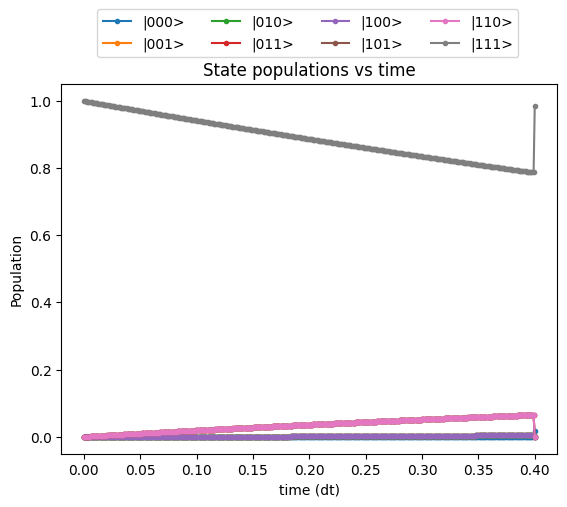

In [10]:
time = np.linspace(0, total_time, len(states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    for j in range(len(states)):
        data.append(np.real(qt.ptrace(states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")

[0.016777174888248685, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9832228251117512]

Text(0, 0.5, 'Fidelity')

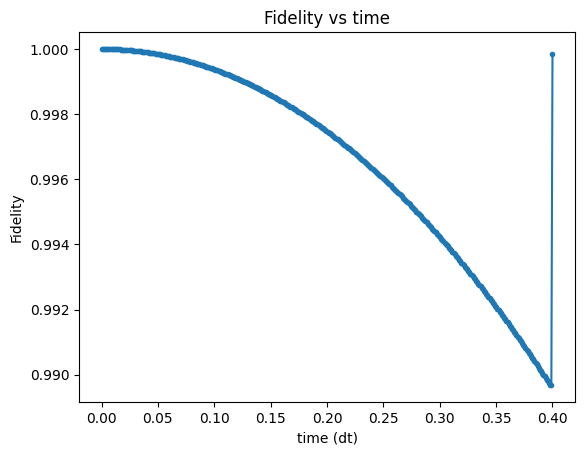

In [11]:
time = np.linspace(0, total_time, len(fids))
# make fidelity plots 
fig, ax = plt.subplots()
ax.plot(time, fids, marker = ".")
ax.set_xlabel("time (dt)")
ax.set_title("Fidelity vs time")
ax.set_ylabel("Fidelity")